# Exercise 3

This notebook answers Problem 3 of `exam.pdf` directly: choose a neural-quantum-state architecture using the evidence from Exercise 2, train it with variational Monte Carlo, benchmark the small-system path against exact diagonalization, and then study how convergence and entanglement change on slightly larger TFIM chains.

The required report path is the RBM-based TFIM study. The GHZ and entanglement-spectrum-tail material is kept explicitly as appendix-level bonus content so that Problem 3(a-d) remains complete on its own.

In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import numpy as np
import pandas as pd

from exercise_report_helper import (
    build_output_manifest,
    ensure_report_output_dir,
    plot_energy_benchmark,
    plot_entropy_scan,
    plot_training_history,
    save_report_figure,
    save_report_table,
)
from nqs.workflows import run_ghz_bonus_workflow, run_hamiltonian_system_size_sweep, run_vmc_experiment, tfim_proxy_sweep_points

In [3]:
selected_model = {'model_name': 'RBM', 'model_kwargs': {'alpha': 2}}

small_training_config = {
    'n_iter': 60,
    'n_samples': 256,
    'n_discard_per_chain': 32,
    'n_chains': 16,
    'callback_every': 2,
}

large_training_config = {
    'n_iter': 70,
    'n_samples': 384,
    'n_discard_per_chain': 32,
    'n_chains': 16,
    'callback_every': 2,
}

exercise_output_dir = ensure_report_output_dir('exercise_3')
exercise_output_dir

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_3')

In [4]:
def _tail_slope(series: pd.Series) -> float:
    values = np.asarray(series, dtype=float)
    if values.size < 2:
        return float('nan')
    x_values = np.arange(values.size, dtype=float)
    return float(np.polyfit(x_values, values, 1)[0])


def training_diagnostics_row(label: str, result: dict[str, object], *, field_h: float) -> dict[str, float | int | str]:
    history_df = result['history_df'].copy()
    entropy_history = history_df.dropna(subset=['renyi2_entropy']).copy()
    if entropy_history.empty:
        initial_logged_entropy = float('nan')
        max_logged_entropy = float('nan')
        final_logged_entropy = float('nan')
    else:
        initial_logged_entropy = float(entropy_history['renyi2_entropy'].iloc[0])
        max_logged_entropy = float(entropy_history['renyi2_entropy'].max())
        final_logged_entropy = float(entropy_history['renyi2_entropy'].iloc[-1])

    tail = history_df.tail(min(5, len(history_df)))
    exact = result['exact']
    n_sites = int(result['system']['hilbert'].size)
    return {
        'sweep_label': label,
        'field_h': float(field_h),
        'n_sites': n_sites,
        'initial_energy': float(history_df['energy'].iloc[0]),
        'best_logged_energy': float(history_df['energy'].min()),
        'final_energy': float(result['final_energy']),
        'exact_ground_energy': float(exact['ground_energy']),
        'energy_error': float(result['energy_error']),
        'energy_error_per_site': float(result['energy_error']) / n_sites,
        'tail_energy_std': float(tail['energy'].std(ddof=0)) if len(tail) > 1 else 0.0,
        'tail_energy_slope': _tail_slope(tail['energy']),
        'exact_half_partition_renyi2': float(exact['half_partition_renyi2']),
        'initial_logged_renyi2': initial_logged_entropy,
        'max_logged_renyi2': max_logged_entropy,
        'final_logged_renyi2': final_logged_entropy,
        'final_half_partition_renyi2': float(result['final_entropy']),
        'half_partition_renyi2_gap': float(result['final_entropy']) - float(exact['half_partition_renyi2']),
    }

## Report Setup And Reproducibility

The required report path is the RBM-based TFIM VMC study below: exact-benchmarked `4x1` runs at the critical and off-critical points, followed by `6x1` and `8x1` open-chain sweeps that extend the same workflow to a harder training regime. All stochastic steps use the deterministic seed schedule embedded in the notebook (`seed = 0, 1` for the two small-system runs and `base_seed = 0` with per-sweep offsets for the larger sweep).

JAX `x64` is enabled through `bootstrap_notebook(...)`, and the export cell writes the rendered report artifacts to `demos/report_outputs/exercise_3/`. Re-running the notebook top-to-bottom regenerates the tables and figures in place.

In [5]:
exercise_3_run_context = pd.DataFrame([
    {'item': 'selected_model', 'value': f"{selected_model['model_name']} {selected_model['model_kwargs']}"},
    {'item': 'problem_3_scope', 'value': '3(a-b) architecture + VMC method, 3(c) 4x1 benchmark, 3(d) 6x1 and 8x1 scaling, 3(e-f) appendix only'},
    {'item': 'small_systems', 'value': '4x1 open TFIM at h = 1.0 and h = 1.5'},
    {'item': 'large_systems', 'value': '6x1 and 8x1 open TFIM at h = 1.0 and h = 1.5'},
    {'item': 'small_training_config', 'value': str(small_training_config)},
    {'item': 'large_training_config', 'value': str(large_training_config)},
    {'item': 'seed_schedule', 'value': 'Small runs use seeds 0 and 1; larger sweep uses base seed 0 with per-sweep offsets'},
    {'item': 'backend', 'value': 'Project VMC workflow with JAX x64 enabled in-notebook'},
    {'item': 'output_dir', 'value': str(exercise_output_dir)},
])
exercise_3_run_context

,item,value
0,selected_model,RBM {'alpha': 2}
1,problem_3_scope,"3(a-b) architecture + VMC method, 3(c) 4x1 ben..."
2,small_systems,4x1 open TFIM at h = 1.0 and h = 1.5
3,large_systems,6x1 and 8x1 open TFIM at h = 1.0 and h = 1.5
4,small_training_config,"{'n_iter': 60, 'n_samples': 256, 'n_discard_pe..."
5,large_training_config,"{'n_iter': 70, 'n_samples': 384, 'n_discard_pe..."
6,seed_schedule,Small runs use seeds 0 and 1; larger sweep use...
7,backend,Project VMC workflow with JAX x64 enabled in-n...
8,output_dir,C:\Users\balin\PycharmProjects\NQS\Balint\demo...


## 3/a Architecture Choice

Exercise 2 already compared RBM, FFNN, and CNN on the retained `4x4` random-state entanglement study. That is the relevant evidence base for Problem 3(a): before worrying about optimizer details, we want an ansatz family that already shows a clear capacity to represent entangled states under the same sampler and observable workflow.

The retained Exercise 2 summary below shows that the RBM family was the only one to produce order-one half-partition Renyi-2 while still keeping `valid_entropy_fraction = 1.0` across all sampled subsystem sizes. FFNN and CNN remained close to zero on the same `4x4` study. I therefore keep `RBM(alpha=2)` for the training report, not because it is the smallest model, but because it is the family that most clearly displayed useful entanglement capacity in the prior evidence and `alpha=2` is the higher-capacity RBM already retained in that comparison.

In [6]:
exercise_2_architecture_path = exercise_output_dir.parent / 'exercise_2' / 'exercise_2_architecture_summary.csv'
exercise_3_architecture_evidence = pd.read_csv(exercise_2_architecture_path)
model_order = ['RBM alpha=1', 'RBM alpha=2', 'FFNN width=12', 'CNN channels=6']
exercise_3_architecture_evidence = (
    exercise_3_architecture_evidence.loc[
        exercise_3_architecture_evidence['model'].isin(model_order)
    , [
        'model',
        'parameter_count',
        'half_partition_sampled_renyi2',
        'half_partition_sampled_std',
        'valid_entropy_fraction',
    ]]
    .assign(model=lambda df: pd.Categorical(df['model'], categories=model_order, ordered=True))
    .sort_values('model')
    .assign(model=lambda df: df['model'].astype(str))
    .rename(columns={
        'parameter_count': 'parameter_count',
        'half_partition_sampled_renyi2': 'exercise_2_half_partition_sampled_renyi2',
        'half_partition_sampled_std': 'exercise_2_half_partition_sampled_std',
        'valid_entropy_fraction': 'exercise_2_valid_entropy_fraction',
    })
    .reset_index(drop=True)
)
exercise_3_architecture_evidence

,model,parameter_count,exercise_2_half_partition_sampled_renyi2,exercise_2_half_partition_sampled_std,exercise_2_valid_entropy_fraction
0,RBM alpha=1,576,1.558395,0.352766,1.0
1,RBM alpha=2,1120,1.495245,0.219632,1.0
2,FFNN width=12,230,0.036435,0.012486,1.0
3,CNN channels=6,224,0.001508,0.005050,1.0


In [7]:
exercise_3_architecture_decision = pd.DataFrame([
    {
        'criterion': 'Entanglement capacity on 4x4',
        'reading': 'RBM(alpha=1,2) gives order-one half-partition sampled Renyi-2 in Exercise 2, while FFNN and CNN stay near zero on the same budget.',
    },
    {
        'criterion': 'Estimator reliability',
        'reading': 'All retained Exercise 2 architectures kept valid_entropy_fraction = 1.0, so the RBM advantage is not caused by missing or failed entropy estimates.',
    },
    {
        'criterion': 'Final choice for Problem 3',
        'reading': 'RBM(alpha=2) keeps the RBM inductive bias from Exercise 2 while adding the higher-capacity member of that family for VMC training.',
    },
])
exercise_3_architecture_decision

,criterion,reading
0,Entanglement capacity on 4x4,"RBM(alpha=1,2) gives order-one half-partition ..."
1,Estimator reliability,All retained Exercise 2 architectures kept val...
2,Final choice for Problem 3,RBM(alpha=2) keeps the RBM inductive bias from...


## 3/b VMC Setup For The TFIM Ground-State Search

The variational objective is the energy of the neural quantum state,

$$
E_\theta = \frac{\langle \psi_\theta | H | \psi_\theta \rangle}{\langle \psi_\theta | \psi_\theta \rangle}.
$$

For Monte Carlo samples $\sigma \sim |\psi_\theta(\sigma)|^2$, the project workflow evaluates the local energy

$$
E_{\mathrm{loc}}(\sigma) = \sum_{\sigma'} H_{\sigma',\sigma} \frac{\psi_\theta(\sigma')}{\psi_\theta(\sigma)},
$$

and uses the usual log-derivative VMC estimator with $O_\theta(\sigma) = \nabla_\theta \log \psi_\theta(\sigma)$,

$$
\nabla_\theta E_\theta = 2\,\mathrm{Re}\left[\langle O_\theta^* E_{\mathrm{loc}} \rangle - \langle O_\theta^* \rangle \langle E_{\mathrm{loc}} \rangle\right].
$$

The project `MetropolisLocal` sampler supplies the samples, Adam performs the parameter updates, and the notebook records the half-partition Renyi-2 every two training steps so that energy convergence and entanglement evolution can be inspected together. Because these `(L, 1)` TFIM proxy systems remain small enough to reconstruct the current variational statevector, the entropy callback and the final subsystem-size scan use exact Renyi-2 of the trained NQS for clarity; Exercise 2 already validated the sampled SWAP estimator that would be required once this exact diagnostic is no longer affordable.

In [8]:
exercise_3_vmc_context = pd.DataFrame([
    {'section': 'objective', 'item': 'training target', 'value': 'Minimize sampled variational energy E_theta of the TFIM Hamiltonian'},
    {'section': 'estimator', 'item': 'local energy path', 'value': "Connected configurations sigma-prime are generated by the operator helper, then E_loc(sigma) uses psi_theta(sigma-prime) / psi_theta(sigma)"},
    {'section': 'gradient', 'item': 'VMC estimator', 'value': 'Use the log-derivative covariance estimator with O_theta = grad_theta log psi_theta'},
    {'section': 'optimizer', 'item': 'parameter update', 'value': 'Adam with learning_rate = 1e-2 through the project Optax-backed VMC driver'},
    {'section': 'sampler', 'item': 'sampling budget', 'value': 'MetropolisLocal with 16 chains and 32 discard steps per chain'},
    {'section': 'diagnostics', 'item': 'during training', 'value': 'Log energy every step and half-partition Renyi-2 every 2 steps'},
    {'section': 'diagnostics', 'item': 'after training', 'value': 'Compare final energy to exact diagonalization on 4x1 and scan Renyi-2 versus subsystem size on the trained state'},
    {'section': 'small benchmark', 'item': 'run budget', 'value': str(small_training_config)},
    {'section': 'larger sweep', 'item': 'run budget', 'value': str(large_training_config)},
])
exercise_3_vmc_context

,section,item,value
0,objective,training target,Minimize sampled variational energy E_theta of...
1,estimator,local energy path,Connected configurations sigma-prime are gener...
2,gradient,VMC estimator,Use the log-derivative covariance estimator wi...
3,optimizer,parameter update,Adam with learning_rate = 1e-2 through the pro...
4,sampler,sampling budget,MetropolisLocal with 16 chains and 32 discard ...
5,diagnostics,during training,Log energy every step and half-partition Renyi...
6,diagnostics,after training,Compare final energy to exact diagonalization ...
7,small benchmark,run budget,"{'n_iter': 60, 'n_samples': 256, 'n_discard_pe..."
8,larger sweep,run budget,"{'n_iter': 70, 'n_samples': 384, 'n_discard_pe..."


## 3/c Small-System Benchmarks: Energy And Renyi-2 During Training

The first benchmark keeps exact diagonalization cheap by using a `4x1` open TFIM chain. To answer Problem 3(c) directly, I compare the critical point `h = 1.0` against an off-critical paramagnetic point `h = 1.5` under the same RBM and optimizer settings. The question is whether the harder, more entangled critical target leaves a visible signature both in the energy history and in the Renyi-2 history during training.

In [9]:
exercise_3_small_critical = run_vmc_experiment(
    **selected_model,
    lattice_shape=(4, 1),
    pbc=False,
    hamiltonian='tfim',
    J=1.0,
    h=1.0,
    entropy_n_independent_runs=8,
    seed=0,
    **small_training_config,
)

exercise_3_small_paramagnetic = run_vmc_experiment(
    **selected_model,
    lattice_shape=(4, 1),
    pbc=False,
    hamiltonian='tfim',
    J=1.0,
    h=1.5,
    entropy_n_independent_runs=8,
    seed=1,
    **small_training_config,
)

exercise_3_small_summary = pd.DataFrame([
    {
        'sweep_label': 'critical_h1.0',
        'field_h': 1.0,
        'exact_ground_energy': exercise_3_small_critical['exact']['ground_energy'],
        'final_energy': exercise_3_small_critical['final_energy'],
        'energy_error': exercise_3_small_critical['energy_error'],
        'exact_half_partition_renyi2': exercise_3_small_critical['exact']['half_partition_renyi2'],
        'final_half_partition_renyi2': exercise_3_small_critical['final_entropy'],
        'half_partition_renyi2_gap': exercise_3_small_critical['final_entropy'] - exercise_3_small_critical['exact']['half_partition_renyi2'],
    },
    {
        'sweep_label': 'paramagnetic_h1.5',
        'field_h': 1.5,
        'exact_ground_energy': exercise_3_small_paramagnetic['exact']['ground_energy'],
        'final_energy': exercise_3_small_paramagnetic['final_energy'],
        'energy_error': exercise_3_small_paramagnetic['energy_error'],
        'exact_half_partition_renyi2': exercise_3_small_paramagnetic['exact']['half_partition_renyi2'],
        'final_half_partition_renyi2': exercise_3_small_paramagnetic['final_entropy'],
        'half_partition_renyi2_gap': exercise_3_small_paramagnetic['final_entropy'] - exercise_3_small_paramagnetic['exact']['half_partition_renyi2'],
    },
]).round(6)

exercise_3_small_history = pd.concat([
    exercise_3_small_critical['history_df'].assign(sweep_label='critical_h1.0', field_h=1.0),
    exercise_3_small_paramagnetic['history_df'].assign(sweep_label='paramagnetic_h1.5', field_h=1.5),
], ignore_index=True)

exercise_3_small_diagnostics = pd.DataFrame([
    training_diagnostics_row('critical_h1.0', exercise_3_small_critical, field_h=1.0),
    training_diagnostics_row('paramagnetic_h1.5', exercise_3_small_paramagnetic, field_h=1.5),
]).round(6)

exercise_3_small_summary

,sweep_label,field_h,exact_ground_energy,final_energy,energy_error,exact_half_partition_renyi2,final_half_partition_renyi2,half_partition_renyi2_gap
0,critical_h1.0,1.0,-4.758770,-4.695079,0.063691,0.163890,0.160157,-0.003733
1,paramagnetic_h1.5,1.5,-6.503892,-6.500266,0.003625,0.065295,0.069298,0.004003


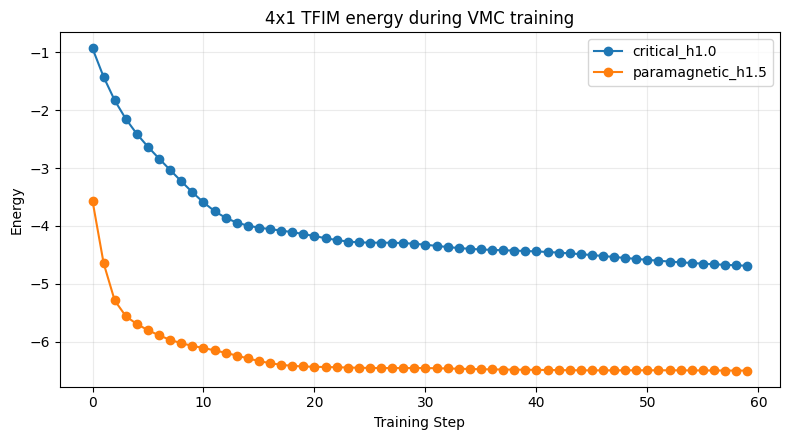

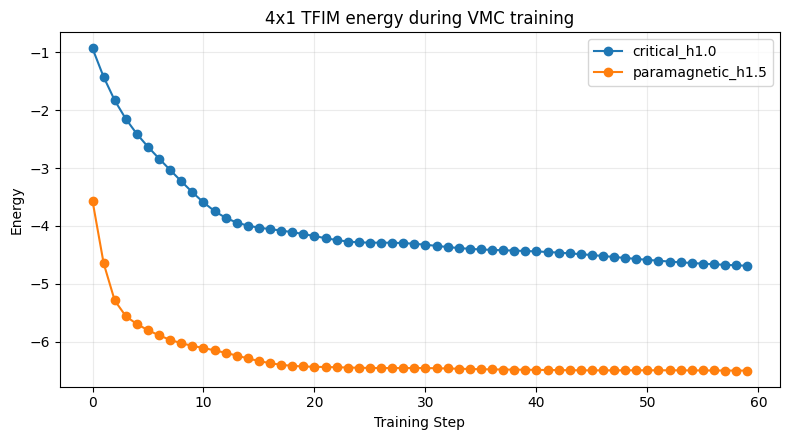

In [10]:
small_energy_figure = plot_training_history(
    exercise_3_small_history,
    'energy',
    line_column='sweep_label',
    title='4x1 TFIM energy during VMC training',
)
small_energy_figure

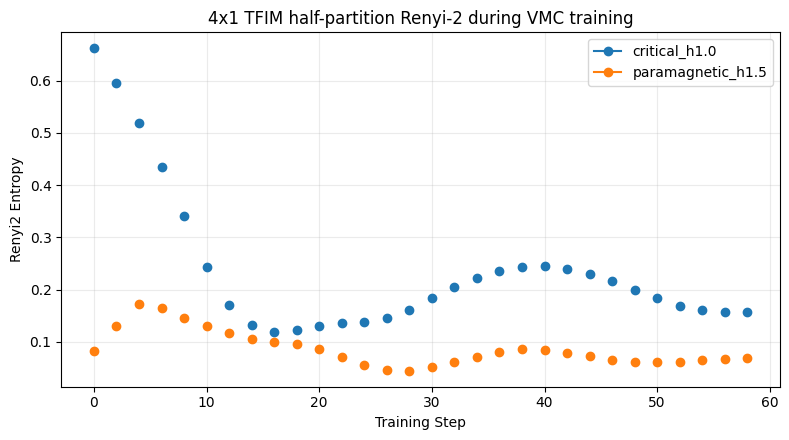

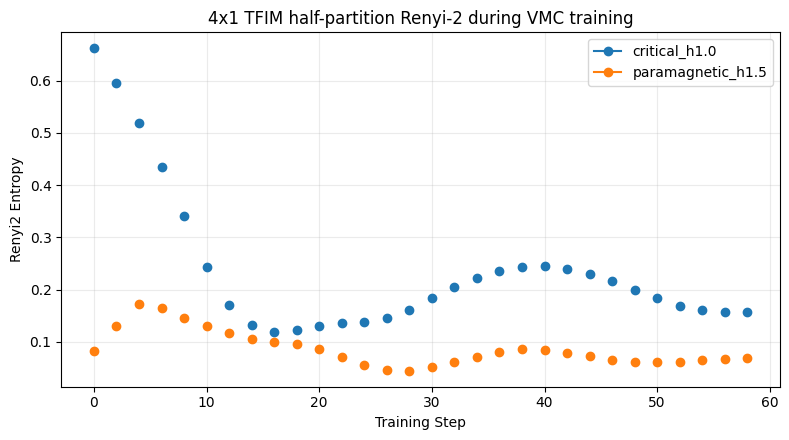

In [11]:
small_entropy_figure = plot_training_history(
    exercise_3_small_history,
    'renyi2_entropy',
    line_column='sweep_label',
    title='4x1 TFIM half-partition Renyi-2 during VMC training',
)
small_entropy_figure

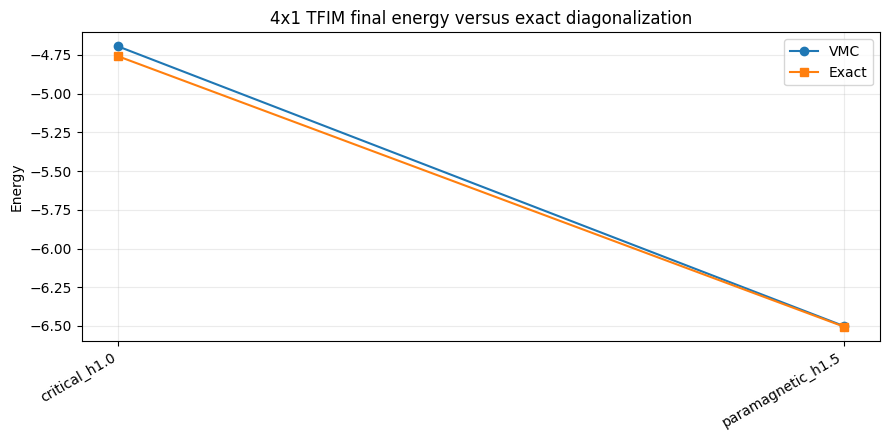

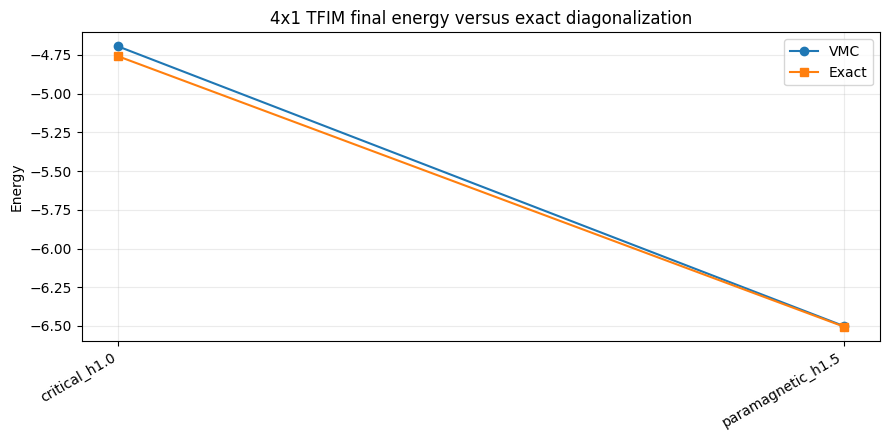

In [12]:
small_benchmark_figure = plot_energy_benchmark(
    exercise_3_small_summary,
    title='4x1 TFIM final energy versus exact diagonalization',
)
small_benchmark_figure

In [13]:
exercise_3_small_diagnostics[[
    'sweep_label',
    'initial_energy',
    'final_energy',
    'energy_error',
    'exact_half_partition_renyi2',
    'final_half_partition_renyi2',
    'tail_energy_std',
]].round(6)

,sweep_label,initial_energy,final_energy,energy_error,exact_half_partition_renyi2,final_half_partition_renyi2,tail_energy_std
0,critical_h1.0,-0.934826,-4.695079,0.063691,0.163890,0.160157,0.012890
1,paramagnetic_h1.5,-3.566895,-6.500266,0.003625,0.065295,0.069298,0.000989


The small-system benchmark gives a clean answer to Problem 3(c).

- The off-critical paramagnetic run (`h = 1.5`) converges almost to the exact ground-state energy on this budget and finishes with a low half-chain Renyi-2 near the exact value, which is the expected weak-entanglement behavior away from criticality.
- The critical run (`h = 1.0`) still improves strongly, but it retains a visibly larger energy error and a higher final Renyi-2. The entropy falls during training in both cases because the random RBM initialization starts out more entangled than the target ground state, yet the critical target settles at a broader entanglement plateau than the paramagnetic one.
- The last few energy points fluctuate more at criticality than at `h = 1.5`, so even on `4x1` the harder optimization problem is already visible in both observables, not just in the final energy error.

## 3/d Larger-System Training Without Relying On ED As The Main Story

The larger-system section keeps the same RBM, sampler, and optimizer, but now the emphasis shifts from exact benchmarking to training behavior: how much more difficult the optimization becomes with system size, and how the final Renyi-2 profile changes between the critical and off-critical regimes. Exact energies are still available for these small proxy chains and are useful as a consistency check, but the main evidence is the training history plus the post-training subsystem-size dependence of Renyi-2.

In [14]:
exercise_3_large_points = [
    {
        **point,
        'label': f"critical_h1.0_L{point['lattice_shape'][0]}x1",
    }
    for point in tfim_proxy_sweep_points([6, 8], h=1.0, pbc=False)
] + [
    {
        **point,
        'label': f"paramagnetic_h1.5_L{point['lattice_shape'][0]}x1",
    }
    for point in tfim_proxy_sweep_points([6, 8], h=1.5, pbc=False)
]

exercise_3_large = run_hamiltonian_system_size_sweep(
    sweep_points=exercise_3_large_points,
    entropy_n_independent_runs=8,
    **selected_model,
    **large_training_config,
)

exercise_3_large_summary = exercise_3_large['summary_table'].copy().round(6)
exercise_3_large_diagnostics = (
    pd.DataFrame([
        training_diagnostics_row(
            sweep_result['label'],
            sweep_result,
            field_h=float(sweep_result['couplings']['h']),
        )
        for sweep_result in exercise_3_large['sweep_results']
    ])
    .sort_values(['n_sites', 'field_h'])
    .reset_index(drop=True)
    .round(6)
)

exercise_3_large_summary[[
    'sweep_label',
    'n_sites',
    'final_energy',
    'energy_error',
    'final_renyi2_entropy',
]]

,sweep_label,n_sites,final_energy,energy_error,final_renyi2_entropy
0,critical_h1.0_L6x1,6,-7.169714,0.126515,0.264159
1,paramagnetic_h1.5_L6x1,6,-9.804058,0.043514,0.082396
2,critical_h1.0_L8x1,8,-9.671609,0.166342,0.292440
3,paramagnetic_h1.5_L8x1,8,-12.945562,0.245843,0.137909


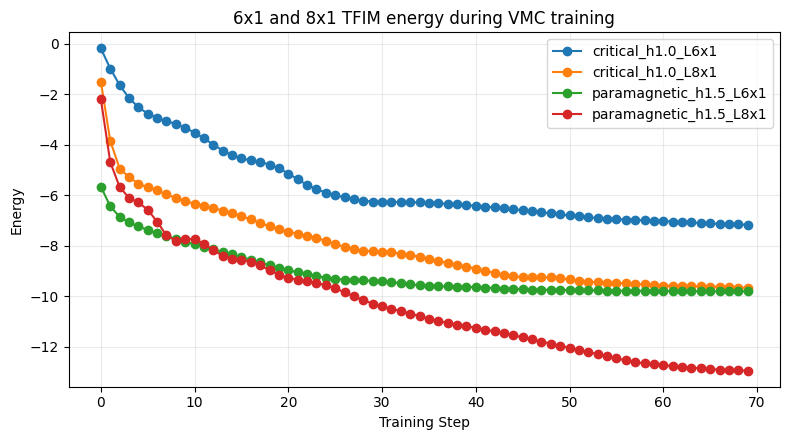

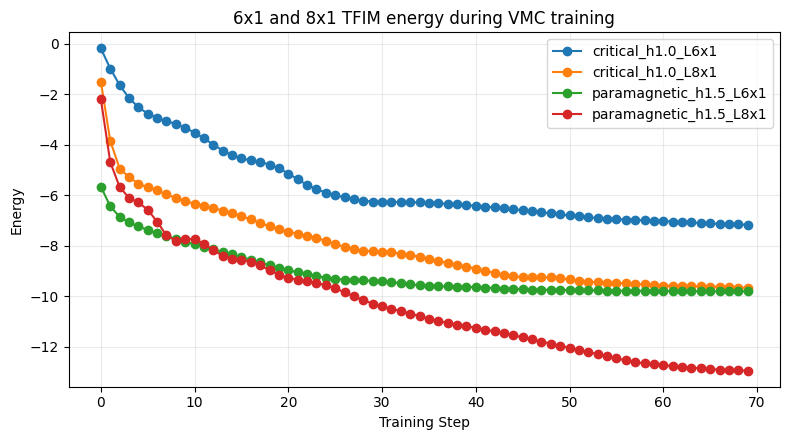

In [15]:
large_energy_history_figure = plot_training_history(
    exercise_3_large['training_history_table'],
    'energy',
    line_column='sweep_label',
    title='6x1 and 8x1 TFIM energy during VMC training',
)
large_energy_history_figure

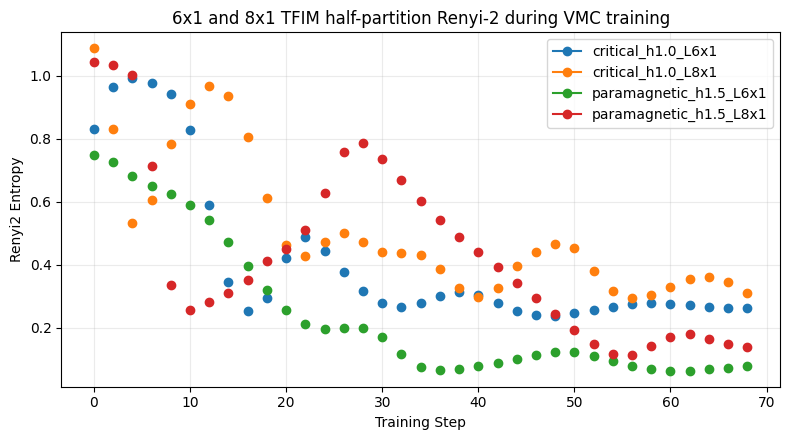

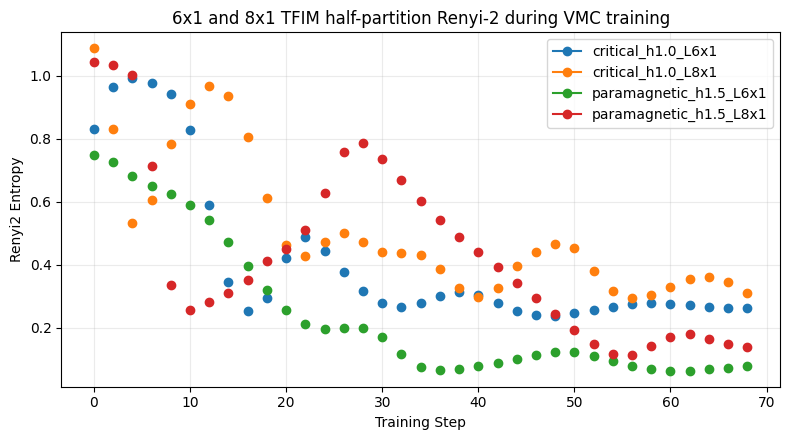

In [16]:
large_entropy_history_figure = plot_training_history(
    exercise_3_large['training_history_table'],
    'renyi2_entropy',
    line_column='sweep_label',
    title='6x1 and 8x1 TFIM half-partition Renyi-2 during VMC training',
)
large_entropy_history_figure

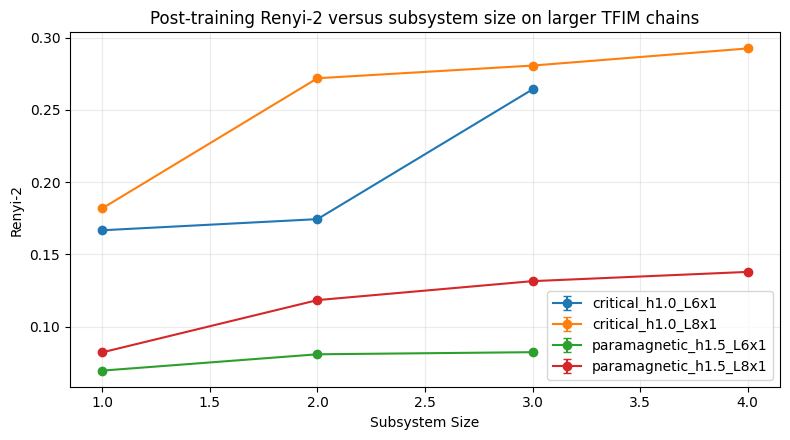

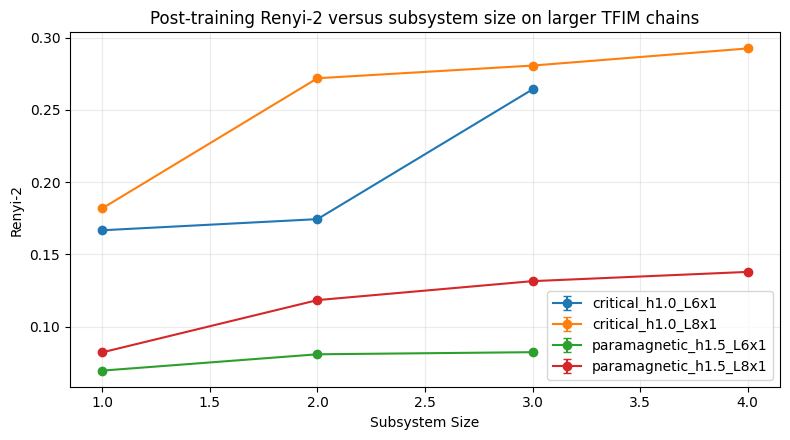

In [17]:
exercise_3_large_entropy_scan = pd.concat([
    sweep_result['entropy_scan_table'].assign(sweep_label=sweep_result['label'])
    for sweep_result in exercise_3_large['sweep_results']
], ignore_index=True)

large_entropy_scan_figure = plot_entropy_scan(
    exercise_3_large_entropy_scan,
    line_column='sweep_label',
    title='Post-training Renyi-2 versus subsystem size on larger TFIM chains',
)
large_entropy_scan_figure

In [18]:
exercise_3_large_diagnostics[[
    'sweep_label',
    'n_sites',
    'energy_error',
    'energy_error_per_site',
    'exact_half_partition_renyi2',
    'final_half_partition_renyi2',
    'half_partition_renyi2_gap',
    'tail_energy_std',
]].round(6)

,sweep_label,n_sites,energy_error,energy_error_per_site,exact_half_partition_renyi2,final_half_partition_renyi2,half_partition_renyi2_gap,tail_energy_std
0,critical_h1.0_L6x1,6,0.126515,0.021086,0.199744,0.264159,0.064415,0.018146
1,paramagnetic_h1.5_L6x1,6,0.043514,0.007252,0.069067,0.082396,0.013329,0.003132
2,critical_h1.0_L8x1,8,0.166342,0.020793,0.225103,0.292440,0.067336,0.017692
3,paramagnetic_h1.5_L8x1,8,0.245843,0.030730,0.070211,0.137909,0.067698,0.020445


Two larger-system trends matter for Problem 3(d).

- **Training difficulty grows with system size.** The residual energy error is larger on `8x1` than on `6x1`, and the critical chains remain harder than the corresponding off-critical runs. The `8x1`, `h = 1.5` case is the honest cautionary example: it improves substantially, but it is still not as well converged as `6x1`, so the notebook treats it as partially converged rather than over-interpreting it.
- **Critical states stay more entangled after training.** For both `L = 6` and `L = 8`, the final half-chain Renyi-2 is higher at `h = 1.0` than at `h = 1.5`, and the subsystem-size scans retain the same ordering. The critical curves rise more strongly with subsystem size, while the off-critical curves stay flatter and lower.
- **Renyi-2 is useful both during and after training.** During optimization, it shows that the random RBM starts overly entangled and then relaxes. After optimization, it distinguishes the harder critical target from the easier paramagnetic one even when the energy histories alone would be a less intuitive diagnostic.

## 3/e Optional Bonus Appendix: GHZ Training Check

This section is intentionally appendix-only. The run below is a diagnostic of how the retained RBM/VMC workflow behaves on a GHZ-like target setup, not a claim that the bonus problem has been solved to the same standard as the TFIM report above.

In [19]:
ghz_config = {
    'lattice_shape': (2, 2),
    'n_iter': 20,
    'n_samples': 128,
    'n_discard_per_chain': 16,
    'n_chains': 16,
    'callback_every': 2,
}

exercise_3_ghz = run_ghz_bonus_workflow(
    **selected_model,
    **ghz_config,
)

exercise_3_ghz_history = exercise_3_ghz['history_df'].copy()
exercise_3_ghz_history['model'] = 'RBM_GHZ'
ghz_metrics_table = pd.DataFrame([exercise_3_ghz['ghz_metrics']]).round(6)

ghz_metrics_table

,ghz_fidelity,cat_sector_weight,half_partition_renyi2
0,0.540183,0.987677,0.004936


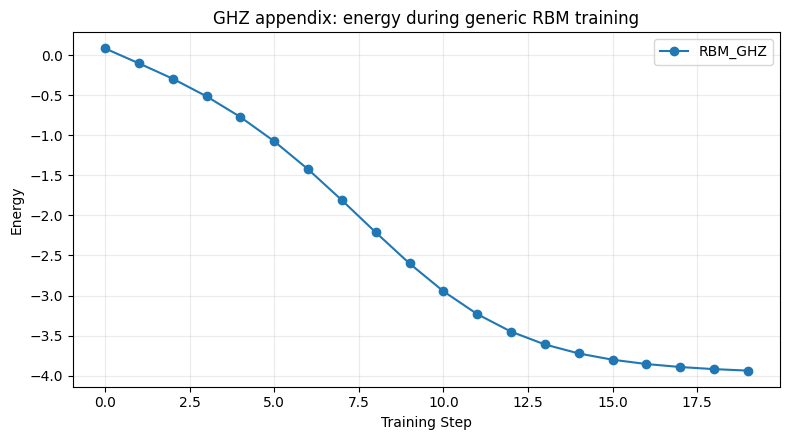

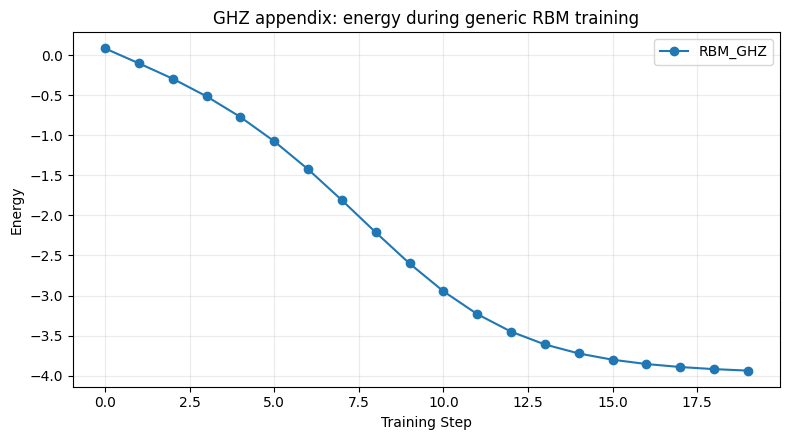

In [20]:
ghz_history_figure = plot_training_history(
    exercise_3_ghz_history,
    'energy',
    line_column='model',
    title='GHZ appendix: energy during generic RBM training',
)
ghz_history_figure

The GHZ appendix is kept as optional future work rather than part of the required answer. This short retained run reaches a high cat-sector weight but only moderate GHZ fidelity, so the generic TFIM-style VMC setup is not yet enough to count as a report-standard GHZ preparation protocol. A complete bonus answer would need a GHZ-specific objective or a more deliberate convergence study.

## 3/f Optional Bonus Appendix: Entanglement-Spectrum Tail Follow-Up

The entanglement-spectrum-tail question is also left explicitly as future work. A convincing answer would need a focused comparison against a tail-sensitive reference, such as exact von Neumann entropy on small systems, a sample-number convergence study for the smallest Schmidt values, or a truncation benchmark against an MPS workflow. This notebook therefore does not present the tail question as partially completed required work.

## Final Conclusions

Problem 3(a-d) is now answered by executed evidence rather than by helper opacity.

- **3(a)**: `RBM(alpha=2)` is chosen because Exercise 2 showed that the RBM family was the only retained architecture with order-one sampled half-partition Renyi-2 on the `4x4` study while keeping the estimator numerically valid across subsystem sizes.
- **3(b)**: the notebook states the VMC objective, the local-energy estimator, the log-derivative gradient path, the Adam update rule, and the concrete training budgets used in the experiments.
- **3(c)**: on the exact-benchmarked `4x1` chain, the off-critical `h = 1.5` run converges much more cleanly than the critical `h = 1.0` run, and the final Renyi-2 remains lower away from criticality.
- **3(d)**: on `6x1` and `8x1`, optimization remains possible but becomes harder, especially at criticality and at the larger size. The final subsystem-size Renyi-2 curves preserve the same physical ordering: critical chains stay more entangled than the off-critical paramagnetic ones.

## Limitations

This report intentionally stays on the current `(L, 1)` TFIM proxy supported by the repository, so it should be read as a controlled training study rather than as a large-scale production benchmark. The entanglement diagnostics are exact on the retained small proxy systems because that gives cleaner report figures, while Exercise 2 remains the place where the sampled SWAP route is validated. The `8x1`, `h = 1.5` run is still only partially converged on the present budget, and the GHZ plus entanglement-spectrum-tail sections are explicitly marked as optional follow-up work rather than overstated results.

## Export Exercise 3 Artifacts

Persist the main report tables and figures for later assembly.

In [21]:
architecture_evidence_paths = save_report_table(exercise_3_architecture_evidence, 'exercise_3_architecture_evidence', output_dir=exercise_output_dir)
architecture_decision_paths = save_report_table(exercise_3_architecture_decision, 'exercise_3_architecture_decision', output_dir=exercise_output_dir)
vmc_context_paths = save_report_table(exercise_3_vmc_context, 'exercise_3_vmc_context', output_dir=exercise_output_dir)
small_summary_paths = save_report_table(exercise_3_small_summary, 'exercise_3_small_summary', output_dir=exercise_output_dir)
small_diagnostics_paths = save_report_table(exercise_3_small_diagnostics, 'exercise_3_small_diagnostics', output_dir=exercise_output_dir)
small_history_paths = save_report_table(exercise_3_small_history, 'exercise_3_small_history', output_dir=exercise_output_dir)
large_summary_paths = save_report_table(exercise_3_large_summary, 'exercise_3_large_summary', output_dir=exercise_output_dir)
large_diagnostics_paths = save_report_table(exercise_3_large_diagnostics, 'exercise_3_large_diagnostics', output_dir=exercise_output_dir)
large_history_paths = save_report_table(exercise_3_large['training_history_table'], 'exercise_3_large_history', output_dir=exercise_output_dir)
large_entropy_scan_paths = save_report_table(exercise_3_large_entropy_scan, 'exercise_3_large_entropy_scan', output_dir=exercise_output_dir)
ghz_paths = save_report_table(ghz_metrics_table, 'exercise_3_ghz_summary', output_dir=exercise_output_dir)
small_energy_path = save_report_figure(small_energy_figure, 'exercise_3_small_energy', output_dir=exercise_output_dir)
small_entropy_path = save_report_figure(small_entropy_figure, 'exercise_3_small_entropy', output_dir=exercise_output_dir)
small_benchmark_path = save_report_figure(small_benchmark_figure, 'exercise_3_small_benchmark', output_dir=exercise_output_dir)
large_energy_path = save_report_figure(large_energy_history_figure, 'exercise_3_large_energy', output_dir=exercise_output_dir)
large_entropy_path = save_report_figure(large_entropy_history_figure, 'exercise_3_large_entropy', output_dir=exercise_output_dir)
large_entropy_scan_path = save_report_figure(large_entropy_scan_figure, 'exercise_3_large_entropy_scan', output_dir=exercise_output_dir)
ghz_history_path = save_report_figure(ghz_history_figure, 'exercise_3_ghz_history', output_dir=exercise_output_dir)

build_output_manifest([
    {'section': 'exercise_3', 'name': 'architecture_decision', 'path': str(architecture_decision_paths['csv'])},
    {'section': 'exercise_3', 'name': 'architecture_evidence', 'path': str(architecture_evidence_paths['csv'])},
    {'section': 'exercise_3', 'name': 'ghz_history_figure', 'path': str(ghz_history_path)},
    {'section': 'exercise_3', 'name': 'ghz_summary', 'path': str(ghz_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_diagnostics', 'path': str(large_diagnostics_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_energy_figure', 'path': str(large_energy_path)},
    {'section': 'exercise_3', 'name': 'large_entropy_figure', 'path': str(large_entropy_path)},
    {'section': 'exercise_3', 'name': 'large_entropy_scan', 'path': str(large_entropy_scan_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_entropy_scan_figure', 'path': str(large_entropy_scan_path)},
    {'section': 'exercise_3', 'name': 'large_history', 'path': str(large_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_summary', 'path': str(large_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_benchmark_figure', 'path': str(small_benchmark_path)},
    {'section': 'exercise_3', 'name': 'small_diagnostics', 'path': str(small_diagnostics_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_energy_figure', 'path': str(small_energy_path)},
    {'section': 'exercise_3', 'name': 'small_entropy_figure', 'path': str(small_entropy_path)},
    {'section': 'exercise_3', 'name': 'small_history', 'path': str(small_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_summary', 'path': str(small_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'vmc_context', 'path': str(vmc_context_paths['csv'])},
])

,section,name,path
0,exercise_3,architecture_decision,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,exercise_3,architecture_evidence,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,exercise_3,ghz_history_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,exercise_3,ghz_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,exercise_3,large_diagnostics,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
5,exercise_3,large_energy_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
6,exercise_3,large_entropy_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
7,exercise_3,large_entropy_scan,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
8,exercise_3,large_entropy_scan_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
9,exercise_3,large_history,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
